In [1]:
import os
from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Sequence

import numpy as np
import matplotlib.pyplot as plt
import ugradio.doppler
from scipy.optimize import curve_fit

from ugradiolab import Spectrum, SpectrumPlot

plt.rcParams['figure.dpi'] = 300


/Users/junruiting/GitHub/ay-121/.venv/lib/python3.14/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
HI_REST_FREQ_HZ = 1420.405751768e6
FWHM_FACTOR = 2.0 * np.sqrt(2.0 * np.log(2.0))


def load_spectra_cached(
    data_dir,
    exclude_fn: Callable[[str], bool] | None = None,
) -> list[Spectrum]:
    """Load pre-built Spectrum products generated by the complete-preview notebook."""
    del exclude_fn  # Backwards-compatible signature; filtering is not used for cached products.

    data_path = Path(data_dir)
    spectra_dir = data_path if data_path.name.endswith('_spectra') else data_path.parent / f"{data_path.name}_spectra"

    if not spectra_dir.is_dir():
        raise FileNotFoundError(
            f"Missing Spectrum product directory: {spectra_dir}. "
            "Run labs/02/lab_2_0_complete_preview.ipynb first."
        )

    spectra_files = sorted(spectra_dir.glob('*.npz'))
    if not spectra_files:
        raise FileNotFoundError(
            f"No Spectrum .npz files found in {spectra_dir}. "
            "Run labs/02/lab_2_0_complete_preview.ipynb to regenerate products."
        )

    print(f"Loading pre-processed Spectrum from {spectra_dir}")
    return [Spectrum.load(path) for path in spectra_files]


def select_spectrum_by_center_freq(
    spectra: Sequence[Spectrum],
    center_freq_hz: float,
    tol_hz: float = 0.5e6,
) -> Spectrum:
    """Return the spectrum whose centre frequency is nearest the target."""
    matches = [
        spectrum for spectrum in spectra
        if abs(spectrum.center_freq - center_freq_hz) < tol_hz
    ]
    if not matches:
        raise ValueError(
            f"No spectrum found near center_freq={center_freq_hz / 1e6:.0f} MHz"
        )
    return min(matches, key=lambda spectrum: abs(spectrum.center_freq - center_freq_hz))


def select_spectra_by_center_freq(
    spectra: Sequence[Spectrum],
    center_freqs_hz: Sequence[float],
    tol_hz: float = 0.5e6,
) -> dict[float, Spectrum]:
    """Return spectra keyed by requested centre frequency."""
    return {
        center_freq_hz: select_spectrum_by_center_freq(
            spectra,
            center_freq_hz,
            tol_hz=tol_hz,
        )
        for center_freq_hz in center_freqs_hz
    }


@dataclass(frozen=True)
class ZenithLSRCorrection:
    ra_deg: float
    dec_deg: float
    jd: float
    velocity_kms: float


@dataclass(frozen=True)
class HIRatioProfile:
    rest_freq_hz: float
    numerator: Spectrum
    denominator: Spectrum
    baseband_mhz: np.ndarray
    raw_ratio: np.ndarray
    ratio_sigma: np.ndarray
    smooth_ratio: np.ndarray
    numerator_topo_velocity_kms: np.ndarray
    denominator_topo_velocity_kms: np.ndarray
    numerator_velocity_kms: np.ndarray
    denominator_velocity_kms: np.ndarray
    velocity_shift_kms: float
    peak_profile: np.ndarray
    peak_profile_smooth: np.ndarray
    peak_sigma: np.ndarray
    dip_profile: np.ndarray
    dip_profile_smooth: np.ndarray
    dip_sigma: np.ndarray


@dataclass(frozen=True)
class GaussianComponentGuess:
    amplitude: float
    center_kms: float
    sigma_kms: float


@dataclass(frozen=True)
class GaussianComponentFit:
    amplitude: float
    center_kms: float
    sigma_kms: float
    amplitude_err: float
    center_err: float
    sigma_err: float

    @property
    def fwhm_kms(self) -> float:
        return FWHM_FACTOR * self.sigma_kms

    @property
    def fwhm_err_kms(self) -> float:
        return FWHM_FACTOR * self.sigma_err


@dataclass(frozen=True)
class HIProfileFit:
    label: str
    component_guesses: tuple[GaussianComponentGuess, ...]
    baseline_poly_order: int
    fit_min_kms: float
    fit_max_kms: float
    popt: np.ndarray
    perr: np.ndarray
    mask: np.ndarray
    chi2_red: float

    @property
    def n_components(self) -> int:
        return len(self.component_guesses)

    @property
    def n_baseline_coeffs(self) -> int:
        return self.baseline_poly_order + 1

    @property
    def components(self) -> tuple[GaussianComponentFit, ...]:
        return tuple(
            GaussianComponentFit(
                amplitude=float(self.popt[3 * i]),
                center_kms=float(self.popt[3 * i + 1]),
                sigma_kms=float(self.popt[3 * i + 2]),
                amplitude_err=float(self.perr[3 * i]),
                center_err=float(self.perr[3 * i + 1]),
                sigma_err=float(self.perr[3 * i + 2]),
            )
            for i in range(self.n_components)
        )

    @property
    def baseline_coeffs(self) -> np.ndarray:
        return self.popt[3 * self.n_components:]

    @property
    def baseline_coeff_errors(self) -> np.ndarray:
        return self.perr[3 * self.n_components:]

    def model(self, vel_kms: np.ndarray) -> np.ndarray:
        return _profile_model(vel_kms, self.popt, self.n_components)

    def baseline(self, vel_kms: np.ndarray) -> np.ndarray:
        return polynomial_baseline(vel_kms, *self.baseline_coeffs)

    def component(self, vel_kms: np.ndarray, index: int) -> np.ndarray:
        component = self.components[index]
        return gaussian_mixture(
            vel_kms,
            component.amplitude,
            component.center_kms,
            component.sigma_kms,
        )

    def print_summary(self) -> None:
        print(
            f"\n{self.label}  ({self.n_components}-component fit + "
            f"poly{self.baseline_poly_order}, {int(self.mask.sum())} channels, "
            f"chi^2_r = {self.chi2_red:.3f})"
        )
        print(
            f"  {'Comp':>4}  {'A':>10}  {'v0_topo (km/s)':>15}  "
            f"{'sigma (km/s)':>13}  {'FWHM (km/s)':>12}"
        )
        print(f"  {'-' * 4}  {'-' * 10}  {'-' * 15}  {'-' * 13}  {'-' * 12}")
        for idx, component in enumerate(self.components, start=1):
            print(
                f"  {idx:>4}  "
                f"{component.amplitude:>8.5f}+/-{component.amplitude_err:<8.5f}  "
                f"{component.center_kms:>+12.2f}+/-{component.center_err:<7.2f}  "
                f"{component.sigma_kms:>10.2f}+/-{component.sigma_err:<7.2f}  "
                f"{component.fwhm_kms:>9.2f}+/-{component.fwhm_err_kms:<7.2f}"
            )
        for idx, (coeff, coeff_err) in enumerate(
            zip(self.baseline_coeffs, self.baseline_coeff_errors)
        ):
            print(f"  baseline c{idx}: {coeff:+.6f} +/- {coeff_err:.6f}  (x = v/100)")


@dataclass(frozen=True)
class ToyHIRatioSimulation:
    signal_velocity_kms: np.ndarray
    reference_velocity_kms: np.ndarray
    continuum_signal: np.ndarray
    continuum_reference: np.ndarray
    line_signal: np.ndarray
    line_reference: np.ndarray
    sky_signal: np.ndarray
    sky_reference: np.ndarray
    power_signal: np.ndarray
    power_reference: np.ndarray
    ratio: np.ndarray
    inverse_ratio: np.ndarray
    lo_separation_kms: float


def zenith_lsr_correction(spectrum: Spectrum) -> ZenithLSRCorrection:
    """Projected LSR correction for a zenith observation."""
    ra_deg = float(np.degrees(spectrum.lst))
    dec_deg = float(spectrum.obs_lat)
    velocity_ms = ugradio.doppler.get_projected_velocity(
        ra=ra_deg,
        dec=dec_deg,
        jd=spectrum.jd,
        obs_lat=spectrum.obs_lat,
        obs_lon=spectrum.obs_lon,
        obs_alt=spectrum.obs_alt,
    )
    return ZenithLSRCorrection(
        ra_deg=ra_deg,
        dec_deg=dec_deg,
        jd=float(spectrum.jd),
        velocity_kms=float(velocity_ms / 1e3),
    )


def extract_hi_ratio_profile(
    numerator: Spectrum,
    denominator: Spectrum,
    *,
    rest_freq_hz: float = HI_REST_FREQ_HZ,
    smooth_kwargs: dict | None = None,
    velocity_shift_kms: float = 0.0,
) -> HIRatioProfile:
    """Extract raw and smoothed ratio-space HI profiles from a dual-LO pair."""
    if smooth_kwargs is None:
        smooth_kwargs = dict(method="savgol", window_length=257, polyorder=3)

    raw_ratio = numerator.ratio_to(denominator)
    ratio_sigma = numerator.ratio_std_to(denominator)
    smooth_ratio = numerator.ratio_to(denominator, smooth_kwargs=smooth_kwargs)

    with np.errstate(divide="ignore", invalid="ignore"):
        dip_profile = 1.0 / raw_ratio - 1.0
        dip_sigma = ratio_sigma / raw_ratio ** 2
        dip_profile_smooth = 1.0 / smooth_ratio - 1.0

    return HIRatioProfile(
        rest_freq_hz=float(rest_freq_hz),
        numerator=numerator,
        denominator=denominator,
        baseband_mhz=numerator.frequency_axis_mhz(mode="baseband"),
        raw_ratio=raw_ratio,
        ratio_sigma=ratio_sigma,
        smooth_ratio=smooth_ratio,
        numerator_topo_velocity_kms=numerator.velocity_axis_kms(rest_freq_hz),
        denominator_topo_velocity_kms=denominator.velocity_axis_kms(rest_freq_hz),
        numerator_velocity_kms=numerator.velocity_axis_kms(
            rest_freq_hz,
            velocity_shift_kms=velocity_shift_kms,
        ),
        denominator_velocity_kms=denominator.velocity_axis_kms(
            rest_freq_hz,
            velocity_shift_kms=velocity_shift_kms,
        ),
        velocity_shift_kms=float(velocity_shift_kms),
        peak_profile=raw_ratio - 1.0,
        peak_profile_smooth=smooth_ratio - 1.0,
        peak_sigma=ratio_sigma,
        dip_profile=dip_profile,
        dip_profile_smooth=dip_profile_smooth,
        dip_sigma=dip_sigma,
    )


def gaussian_mixture(vel_kms: np.ndarray, *params: float) -> np.ndarray:
    """Sum of Gaussian components stored as [A1, v1, s1, A2, v2, s2, ...]."""
    result = np.zeros_like(vel_kms, dtype=float)
    for idx in range(len(params) // 3):
        amplitude = params[3 * idx]
        center = params[3 * idx + 1]
        sigma = params[3 * idx + 2]
        result += amplitude * np.exp(-0.5 * ((vel_kms - center) / sigma) ** 2)
    return result


def polynomial_baseline(vel_kms: np.ndarray, *coeffs: float) -> np.ndarray:
    """Polynomial baseline in x = v / 100 for stable coefficients."""
    scaled_vel = vel_kms / 100.0
    result = np.zeros_like(vel_kms, dtype=float)
    for order, coeff in enumerate(coeffs):
        result += coeff * scaled_vel ** order
    return result


def fit_hi_profile(
    vel_kms: np.ndarray,
    profile_raw: np.ndarray,
    sigma_profile: np.ndarray,
    *,
    initial_guesses: Sequence[GaussianComponentGuess | tuple[float, float, float]],
    baseline_poly_order: int = 1,
    fit_min_kms: float = -120.0,
    fit_max_kms: float = 120.0,
    label: str = "",
) -> HIProfileFit:
    """Fit Gaussian components plus a low-order polynomial baseline."""
    component_guesses = tuple(_coerce_guess(guess) for guess in initial_guesses)
    mask = (
        np.isfinite(vel_kms)
        & np.isfinite(profile_raw)
        & np.isfinite(sigma_profile)
        & (sigma_profile > 0)
        & (vel_kms >= fit_min_kms)
        & (vel_kms <= fit_max_kms)
    )
    v_fit = vel_kms[mask]
    p_fit = profile_raw[mask]
    s_fit = sigma_profile[mask]

    n_components = len(component_guesses)
    n_base = baseline_poly_order + 1
    p0_gauss = [
        value
        for guess in component_guesses
        for value in (guess.amplitude, guess.center_kms, guess.sigma_kms)
    ]

    outer = np.abs(v_fit) > 80.0
    if outer.sum() <= baseline_poly_order:
        outer = np.ones_like(v_fit, dtype=bool)
    coeff_high_to_low = np.polyfit(
        v_fit[outer] / 100.0,
        p_fit[outer],
        deg=baseline_poly_order,
        w=1.0 / np.maximum(s_fit[outer], 1e-9),
    )
    p0_base = coeff_high_to_low[::-1].tolist()
    p0 = p0_gauss + p0_base

    lower_gauss = [0.0, -200.0, 1.0] * n_components
    upper_gauss = [np.inf, 200.0, 200.0] * n_components
    lower_base = [-np.inf] * n_base
    upper_base = [np.inf] * n_base

    popt, pcov = curve_fit(
        lambda vel, *params: _profile_model(vel, np.asarray(params), n_components),
        v_fit,
        p_fit,
        p0=p0,
        sigma=s_fit,
        absolute_sigma=True,
        bounds=(lower_gauss + lower_base, upper_gauss + upper_base),
        maxfev=50000,
    )
    perr = np.sqrt(np.diag(pcov))
    residuals = p_fit - _profile_model(v_fit, popt, n_components)
    chi2_red = float(np.sum((residuals / s_fit) ** 2) / max(mask.sum() - len(p0), 1))

    return HIProfileFit(
        label=label,
        component_guesses=component_guesses,
        baseline_poly_order=baseline_poly_order,
        fit_min_kms=float(fit_min_kms),
        fit_max_kms=float(fit_max_kms),
        popt=np.asarray(popt, dtype=float),
        perr=np.asarray(perr, dtype=float),
        mask=mask,
        chi2_red=chi2_red,
    )


def print_lsr_fit_summary(
    fits: Sequence[tuple[str, HIProfileFit]],
    *,
    velocity_shift_kms: float,
) -> None:
    """Print topocentric and LSR centroid summaries for fitted components."""
    print(
        f"\nLSR correction: Delta v = {velocity_shift_kms:+.4f} km/s  "
        f"(v_LSR = v_topo + Delta v)"
    )
    print(f"  {'Band':<12}  {'Comp':>4}  {'v0_topo (km/s)':>16}  {'v0_LSR (km/s)':>15}")
    print(f"  {'-' * 12}  {'-' * 4}  {'-' * 16}  {'-' * 15}")
    for band_label, fit in fits:
        for idx, component in enumerate(fit.components, start=1):
            v0_lsr = component.center_kms + velocity_shift_kms
            print(
                f"  {band_label:<12}  {idx:>4}  "
                f"{component.center_kms:>+13.2f}+/-{component.center_err:<5.2f}  "
                f"{v0_lsr:>+12.2f}+/-{component.center_err:<5.2f}"
            )


def simulate_hi_ratio_signature(
    template_spectrum: Spectrum,
    component_params: Sequence[float],
    *,
    signal_center_freq_hz: float = 1420e6,
    reference_center_freq_hz: float = 1421e6,
    rest_freq_hz: float = HI_REST_FREQ_HZ,
) -> ToyHIRatioSimulation:
    """Toy continuum plus line simulation for the two-LO ratio method."""
    component_params = np.asarray(component_params, dtype=float)
    delta_f_hz = template_spectrum.freqs - template_spectrum.center_freq

    signal_freqs = signal_center_freq_hz + delta_f_hz
    reference_freqs = reference_center_freq_hz + delta_f_hz

    signal_velocity = 2.99792458e5 * (rest_freq_hz - signal_freqs) / rest_freq_hz
    reference_velocity = 2.99792458e5 * (rest_freq_hz - reference_freqs) / rest_freq_hz

    continuum_signal = 1.0 + 0.05 * (signal_velocity / 250.0) + 0.03 * (signal_velocity / 250.0) ** 2
    continuum_reference = 1.0 + 0.05 * (reference_velocity / 250.0) + 0.03 * (reference_velocity / 250.0) ** 2
    line_signal = gaussian_mixture(signal_velocity, *component_params)
    line_reference = gaussian_mixture(reference_velocity, *component_params)
    sky_signal = continuum_signal + line_signal
    sky_reference = continuum_reference + line_reference

    x = delta_f_hz / np.max(np.abs(delta_f_hz))
    bandpass = 1.0 - 0.30 * x ** 2 + 0.05 * x ** 4

    power_signal = bandpass * sky_signal
    power_reference = bandpass * sky_reference
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = power_signal / power_reference
        inverse_ratio = power_reference / power_signal

    lo_separation_kms = float(
        2.99792458e5 * (reference_center_freq_hz - signal_center_freq_hz) / rest_freq_hz
    )
    return ToyHIRatioSimulation(
        signal_velocity_kms=signal_velocity,
        reference_velocity_kms=reference_velocity,
        continuum_signal=continuum_signal,
        continuum_reference=continuum_reference,
        line_signal=line_signal,
        line_reference=line_reference,
        sky_signal=sky_signal,
        sky_reference=sky_reference,
        power_signal=power_signal,
        power_reference=power_reference,
        ratio=ratio,
        inverse_ratio=inverse_ratio,
        lo_separation_kms=lo_separation_kms,
    )


def _coerce_guess(
    guess: GaussianComponentGuess | tuple[float, float, float],
) -> GaussianComponentGuess:
    if isinstance(guess, GaussianComponentGuess):
        return guess
    amplitude, center_kms, sigma_kms = guess
    return GaussianComponentGuess(
        amplitude=float(amplitude),
        center_kms=float(center_kms),
        sigma_kms=float(sigma_kms),
    )


def _profile_model(
    vel_kms: np.ndarray,
    params: np.ndarray,
    n_components: int,
) -> np.ndarray:
    gauss_params = params[: 3 * n_components]
    base_params = params[3 * n_components:]
    return gaussian_mixture(vel_kms, *gauss_params) + polynomial_baseline(
        vel_kms,
        *base_params,
    )


In [3]:
DATA_ROOT = os.path.join('../..', '..', '..', 'data', 'lab02')
LONG_DIR = os.path.join(DATA_ROOT, 'standard_combined_spectra')

long_spectra = sorted(load_spectra_cached(LONG_DIR), key=lambda s: s.center_freq)

for spectrum in long_spectra:
    print(
        f'  LO={spectrum.center_freq/1e6:.0f} MHz   '
        f'HI offset={(HI_REST_FREQ_HZ - spectrum.center_freq)/1e6:+.3f} MHz'
    )


Loading pre-processed Spectrum from ../../../data/lab02/standard_combined_spectra
  LO=1420 MHz   HI offset=+0.406 MHz
  LO=1421 MHz   HI offset=-0.594 MHz


# Lab 2.1 Analysis — Bandpass Calibration via Spectral Division

Prerequisite: run `lab_2_0_complete_preview.ipynb` to generate `*_combined_spectra` products used below.

## 1 · The signal chain and the FIR bandpass

The RTL-SDR processes the sky signal in two stages before delivering samples:

**Stage 1 — Downconversion.**  
The local oscillator (LO) at frequency $f_c$ mixes the sky down to baseband, so an astronomical signal at absolute frequency $f$ appears at baseband offset $\Delta f = f - f_c$.

**Stage 2 — FIR decimation filter.**  
The RTL chip applies a fixed finite-impulse-response (FIR) filter $h[n]$ in the time domain before passing samples to the host. In the time domain this is a convolution:

$$x_\text{out}[n] = \bigl(x_\text{in} * h\bigr)[n]$$

By the **convolution theorem**, convolution in time is multiplication in frequency:

$$X_\text{out}(\Delta f) = H(\Delta f) \cdot X_\text{in}(\Delta f)$$

where $H(\Delta f) = \mathcal{F}\{h\}$ is the filter's complex frequency response. The observed power spectral density (PSD) is therefore

$$\boxed{P_\text{obs}(\Delta f) = \lvert H(\Delta f) \rvert^2 \cdot S_\text{sky}(f_c + \Delta f)}$$

The characteristic shape seen in every raw spectrum — high at band centre, rolling off toward the edges — is $\lvert H(\Delta f) \rvert^2$, the **power response of the FIR filter**, not a property of the sky. A polynomial or polynomial-fit baseline removal can approximate this shape but cannot recover it exactly.

---

## 2 · Bandpass calibration by spectral division

Because $\lvert H(\Delta f) \rvert^2$ depends only on baseband offset and the hardware configuration (not on $f_c$), it is **identical** for any two observations taken with the same SDR settings. For two observations at LO frequencies $f_{c,1}$ and $f_{c,2}$:

$$P_1(\Delta f) = \lvert H(\Delta f) \rvert^2 \cdot S_\text{sky}(f_{c,1} + \Delta f)$$
$$P_2(\Delta f) = \lvert H(\Delta f) \rvert^2 \cdot S_\text{sky}(f_{c,2} + \Delta f)$$

Dividing bin-by-bin at the **same baseband index**:

$$R(\Delta f) \;\equiv\; \frac{P_1(\Delta f)}{P_2(\Delta f)} \;=\; \frac{\lvert H(\Delta f) \rvert^2 \cdot S_\text{sky}(f_{c,1} + \Delta f)}{\lvert H(\Delta f) \rvert^2 \cdot S_\text{sky}(f_{c,2} + \Delta f)} \;=\; \frac{S_\text{sky}(f_{c,1} + \Delta f)}{S_\text{sky}(f_{c,2} + \Delta f)}$$

**$\lvert H(\Delta f) \rvert^2$ cancels exactly.** $R(\Delta f)$ is a purely astronomical quantity: the ratio of sky brightness temperatures $\lvert f_{c,2} - f_{c,1} \rvert$ apart, sampled at the baseband grid of the first observation. No knowledge of the filter coefficients is required.

---

## 3 · Application to the 1420 / 1421 MHz pair

The HI 21-cm line sits at $f_\text{HI} = 1420.406$ MHz. The two extreme observations give:

| Observation | $f_c$ | HI position $\Delta f = f_\text{HI} - f_c$ |
|:---|:---:|:---:|
| Signal | 1420 MHz | $+0.406$ MHz |
| Reference | 1421 MHz | $-0.594$ MHz |

Computing $R(\Delta f) = P_{1420}(\Delta f)\;/\;P_{1421}(\Delta f)$:

- **At $\Delta f = +0.406$ MHz** — the 1420 MHz capture contains the HI line; the 1421 MHz capture sees only continuum at that offset → $R > 1$, a **peak**.
- **At $\Delta f = -0.594$ MHz** — the 1420 MHz capture sees continuum; the 1421 MHz capture contains the HI line → $R < 1$, a **dip**.
- **Everywhere else** — both captures see spectrally smooth continuum, so $R \approx 1$.

The pair of features (peak and dip separated by $f_{c,2} - f_{c,1} = 1$ MHz) is a direct signature of a narrow spectral line sitting between the two LO settings. The true line profile can be read from either feature alone.


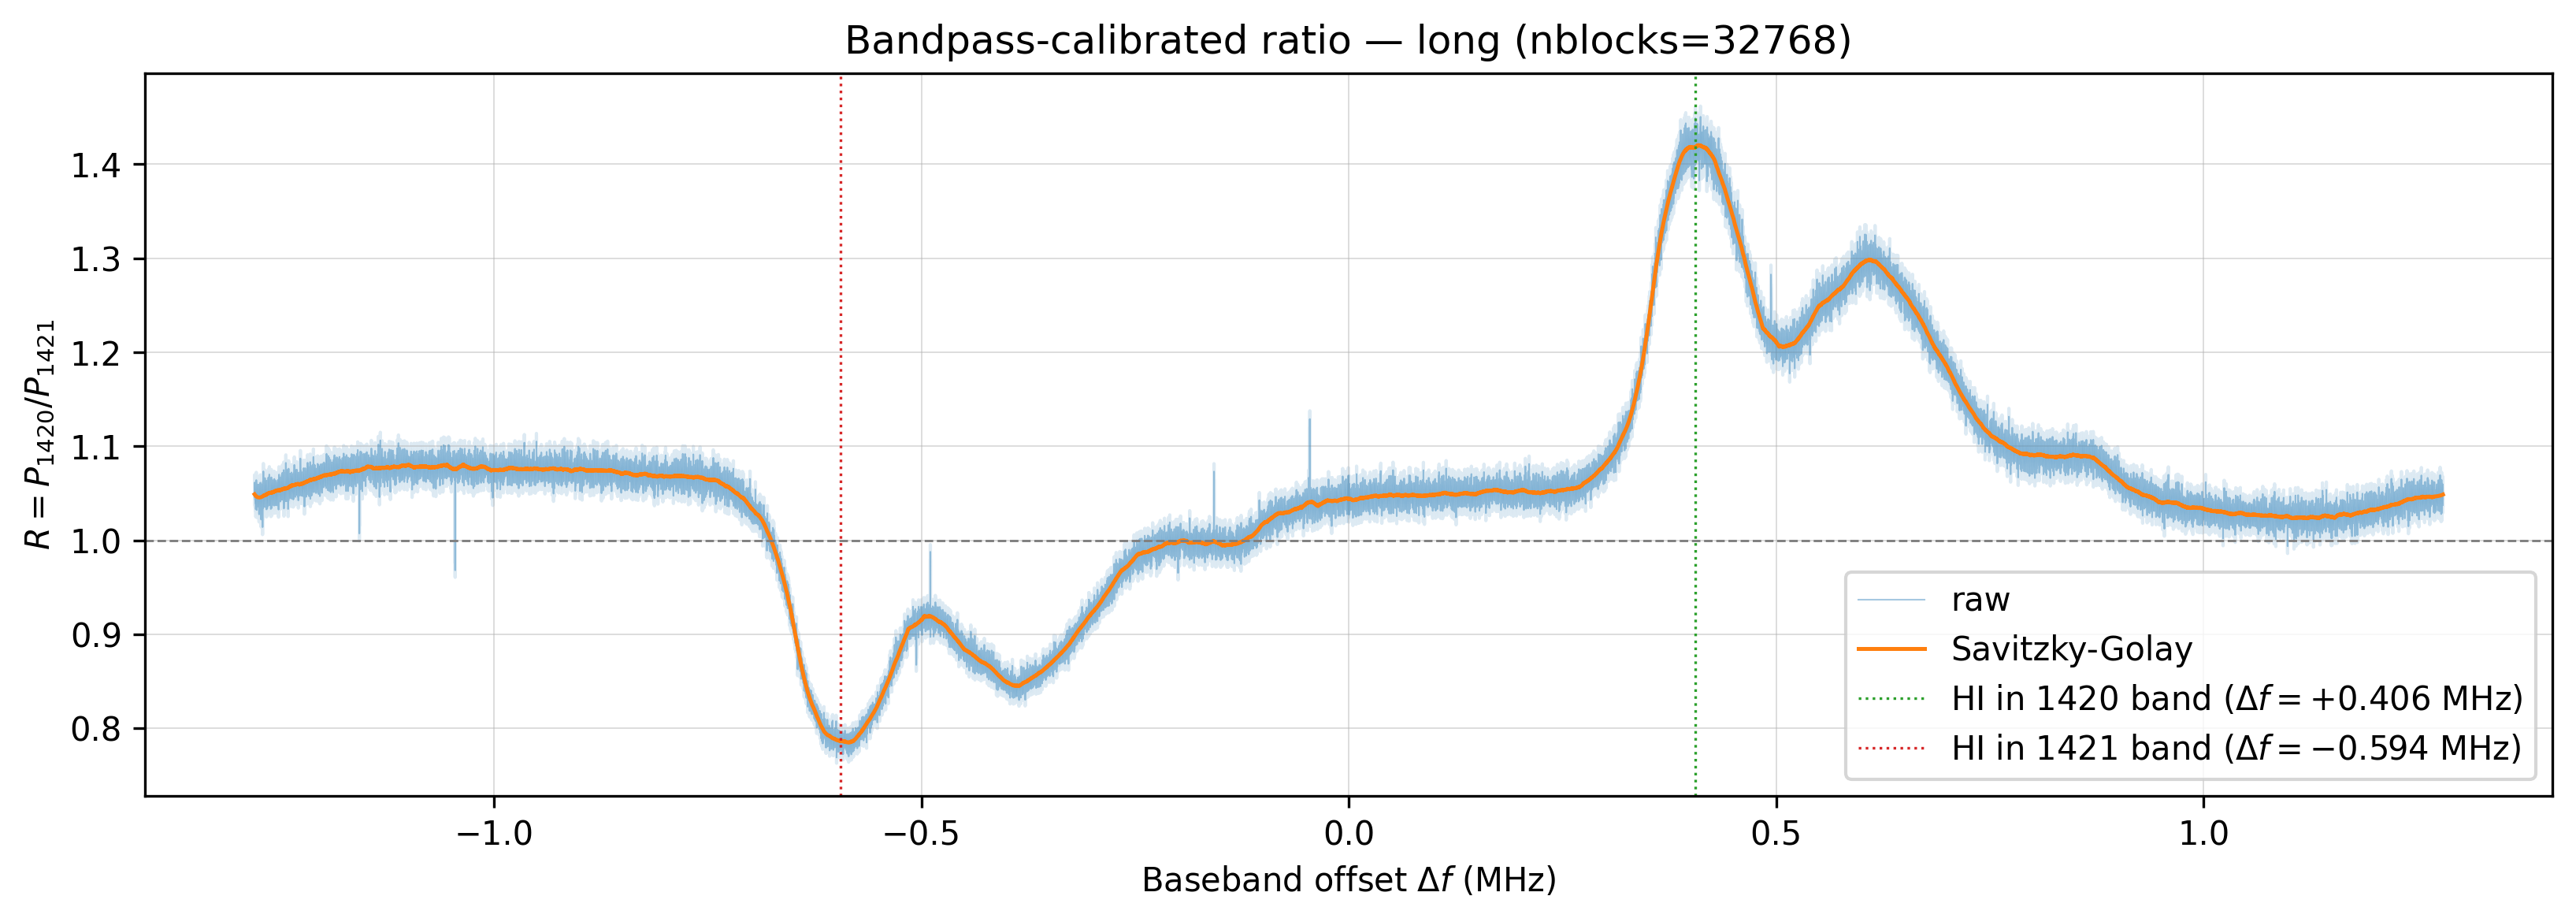

In [4]:
long_1420 = select_spectrum_by_center_freq(long_spectra, 1420e6, tol_hz=0.5e6)
long_1421 = select_spectrum_by_center_freq(long_spectra, 1421e6, tol_hz=0.5e6)

savgol_kwargs = dict(method='savgol', window_length=257, polyorder=3)
ratio_profile = extract_hi_ratio_profile(
    long_1420,
    long_1421,
    rest_freq_hz=HI_REST_FREQ_HZ,
    smooth_kwargs=savgol_kwargs,
)

R = ratio_profile.raw_ratio
sigma_R = ratio_profile.ratio_sigma
R_smooth = ratio_profile.smooth_ratio

ax = SpectrumPlot.coerce(long_1420).plot_ratio(
    long_1421,
    title=fr'Bandpass-calibrated ratio — long (nblocks={long_1420.nblocks})',
    smooth_kwargs=savgol_kwargs,
    x_mode='baseband',
    color='C0',
    smooth_color='C1',
    raw_label='raw',
    smooth_label='Savitzky-Golay',
    reference_lines=[
        {
            'x': (HI_REST_FREQ_HZ - 1420e6) / 1e6,
            'color': 'C2',
            'lw': 0.8,
            'linestyle': ':',
            'label': fr'HI in 1420 band ($\Delta f = {(HI_REST_FREQ_HZ - 1420e6)/1e6:+.3f}$ MHz)',
        },
        {
            'x': (HI_REST_FREQ_HZ - 1421e6) / 1e6,
            'color': 'C3',
            'lw': 0.8,
            'linestyle': ':',
            'label': fr'HI in 1421 band ($\Delta f = {(HI_REST_FREQ_HZ - 1421e6)/1e6:+.3f}$ MHz)',
        },
    ],
    ylabel=r'$R = P_{1420} / P_{1421}$',
)
ax.figure.tight_layout()
plt.show()


In [5]:
lsr_correction = zenith_lsr_correction(long_1420)
v_lsr_kms = lsr_correction.velocity_kms

print(f'Zenith pointing:  RA = {lsr_correction.ra_deg:.3f}°   Dec = {lsr_correction.dec_deg:.3f}°')
print(f'JD of observation: {lsr_correction.jd:.5f}')
print(f'LSR correction (v_projected): {v_lsr_kms:+.4f} km/s')
print(f'  v_LSR = v_topo + ({v_lsr_kms:+.4f} km/s)')


Zenith pointing:  RA = 0.411°   Dec = 37.873°
JD of observation: 2461105.38621
LSR correction (v_projected): -13.6737 km/s
  v_LSR = v_topo + (-13.6737 km/s)


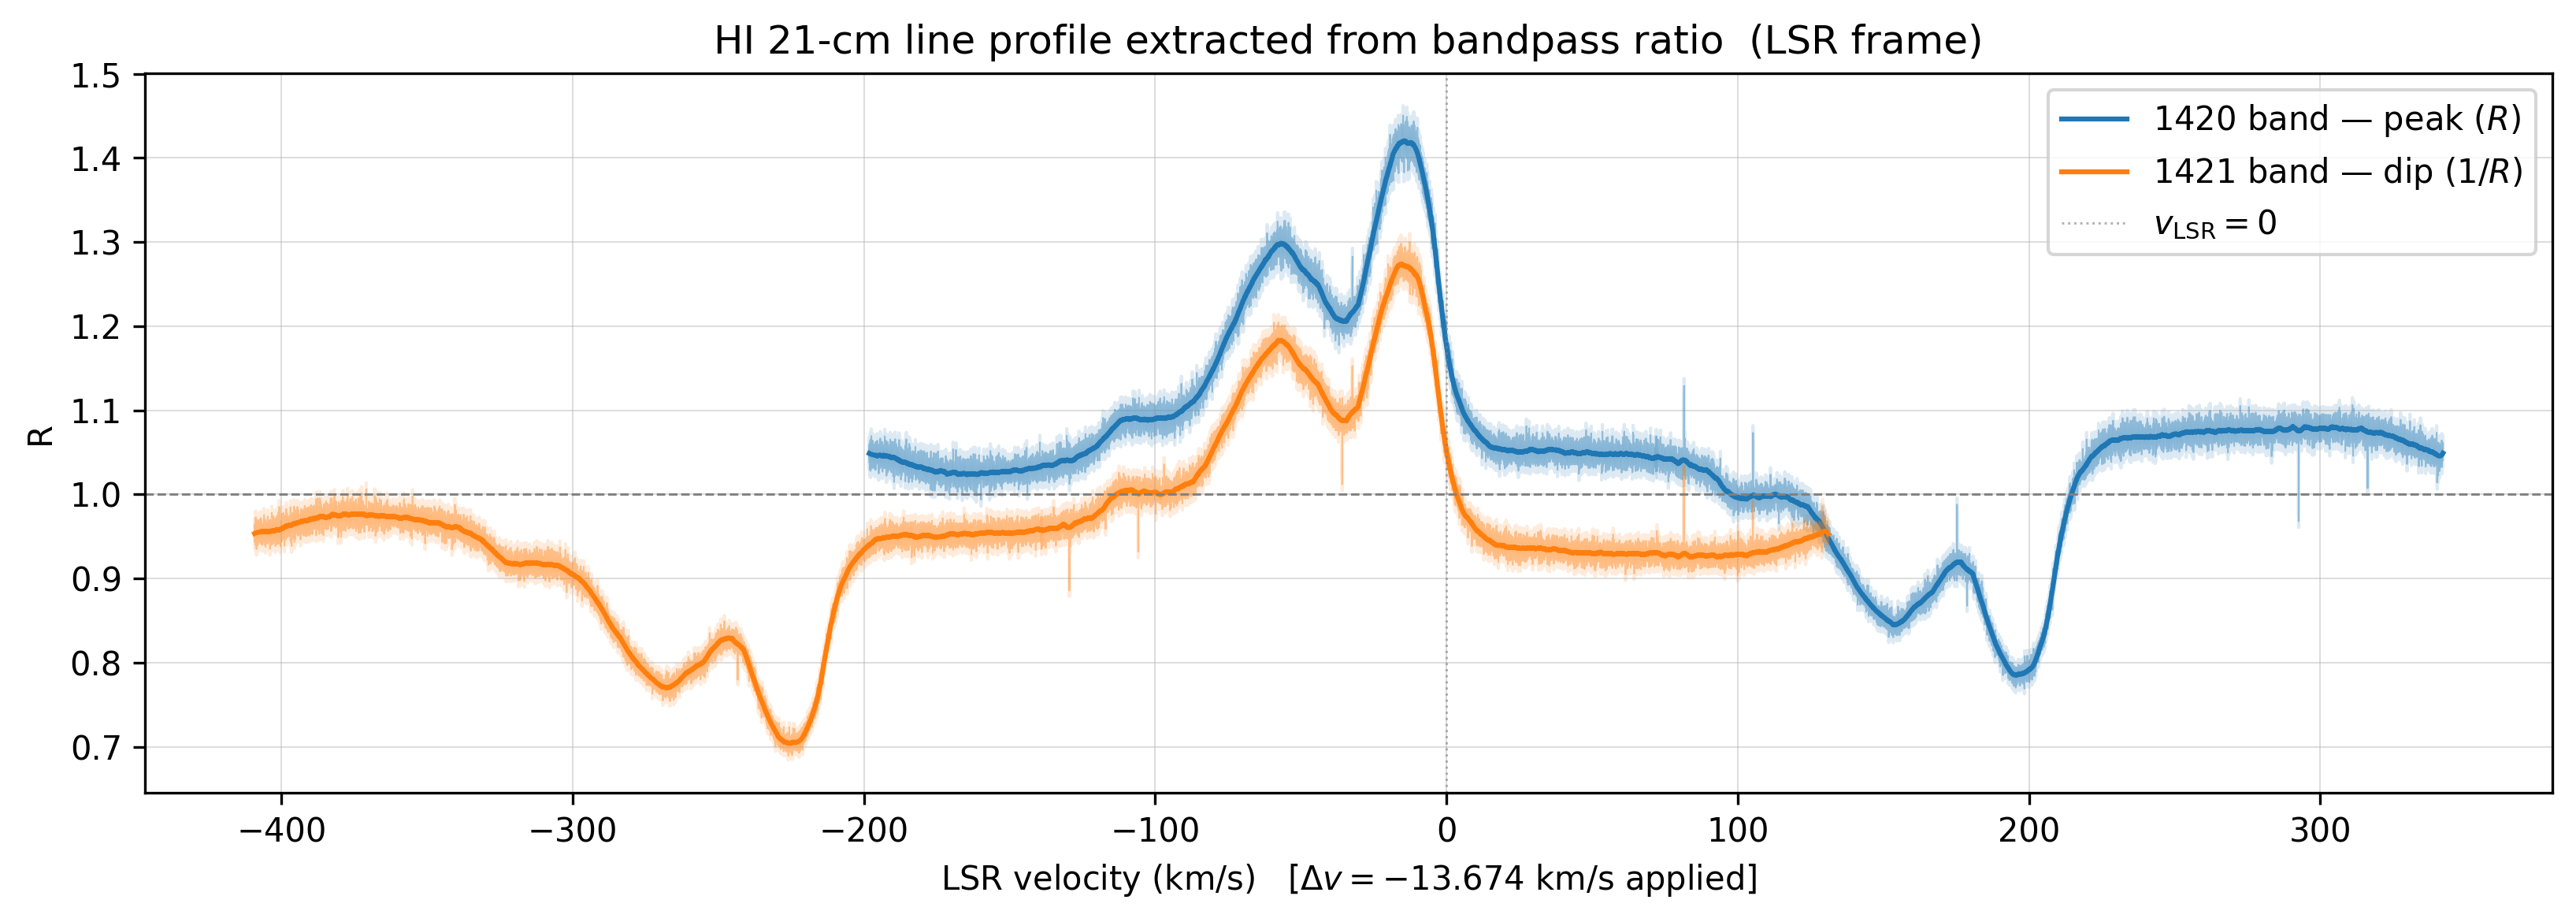

In [6]:
ratio_profile_lsr = extract_hi_ratio_profile(
    long_1420,
    long_1421,
    rest_freq_hz=HI_REST_FREQ_HZ,
    smooth_kwargs=savgol_kwargs,
    velocity_shift_kms=v_lsr_kms,
)

vel_1420 = ratio_profile_lsr.numerator_velocity_kms
vel_1421 = ratio_profile_lsr.denominator_velocity_kms
profile_peak = ratio_profile_lsr.peak_profile
sigma_peak = ratio_profile_lsr.peak_sigma
profile_dip = ratio_profile_lsr.dip_profile
sigma_dip = ratio_profile_lsr.dip_sigma
profile_peak_smooth = ratio_profile_lsr.peak_profile_smooth
profile_dip_smooth = ratio_profile_lsr.dip_profile_smooth

fig, ax = plt.subplots(figsize=(11, 4), dpi=300)

ax.fill_between(vel_1420,
                (profile_peak - sigma_peak + 1),
                (profile_peak + sigma_peak + 1),
                alpha=0.15, color='C0')
ax.plot(vel_1420, profile_peak + 1,
        lw=0.5, alpha=0.4, color='C0')
ax.plot(vel_1420, profile_peak_smooth + 1,
        lw=1.5, color='C0', label=r'1420 band — peak ($R$)')

ax.fill_between(vel_1421,
                (profile_dip - sigma_dip + 1),
                (profile_dip + sigma_dip + 1),
                alpha=0.15, color='C1')
ax.plot(vel_1421, profile_dip + 1,
        lw=0.5, alpha=0.4, color='C1')
ax.plot(vel_1421, profile_dip_smooth + 1,
        lw=1.5, color='C1', label=r'1421 band — dip ($1/R$)')

ax.axhline(1,  color='gray', lw=0.7, linestyle='--')
ax.axvline(0,  color='gray', lw=0.7, linestyle=':', alpha=0.6, label=r'$v_\mathrm{LSR}=0$')
ax.set_xlabel(f'LSR velocity (km/s)   [$\\Delta v = {v_lsr_kms:+.3f}$ km/s applied]')
ax.set_ylabel('R')
ax.set_title('HI 21-cm line profile extracted from bandpass ratio  (LSR frame)')
ax.legend()
ax.grid(True, lw=0.4, alpha=0.5)
fig.tight_layout()
plt.show()


## 4 · Gaussian Decomposition of the HI Line Profile

We fit a sum of $N$ Gaussians to both the **1420-band peak** ($R - 1$) and the **1421-band dip** ($1/R - 1$) profiles.

A single Gaussian component is

$$
G_k(v) = A_k\,\exp\!\left[-\frac{(v - v_{0,k})^2}{2\sigma_k^2}\right],
$$

where $A_k$ is amplitude, $v_{0,k}$ is centroid velocity (km s$^{-1}$), and $\sigma_k$ is width (km s$^{-1}$).
The full line model is

$$
P_{\mathrm{model}}(v) = \sum_{k=1}^{N} G_k(v) + \sum_{m=0}^{M} c_m\left(\frac{v}{100}\right)^m,
$$

with the second term representing a low-order polynomial baseline.
The FWHM of each Gaussian is

$$
\mathrm{FWHM}_k = 2\sqrt{2\ln 2}\,\sigma_k.
$$

To account for broad residual structure in the ratio spectrum, we fit the Gaussians together with a low-order polynomial baseline over a restricted velocity window. Fits are performed with `scipy.optimize.curve_fit` using per-channel uncertainties propagated from `Spectrum.std`.


In [7]:
vel_1420_kms = ratio_profile.numerator_topo_velocity_kms
vel_1421_kms = ratio_profile.denominator_topo_velocity_kms

# Velocity window to fit within (km/s).
VEL_FIT_MIN = -120.0
VEL_FIT_MAX = +120.0

# Polynomial order for the additive baseline in profile space.
# 0 = constant offset, 1 = offset + slope, 2 = quadratic, etc.
BASELINE_POLY_ORDER = 1

# Initial guesses: list of (amplitude, centre_kms, sigma_kms) per component.
# Amplitudes are in units of (R - 1) — fractional excess above the continuum.
INITIAL_GUESSES = [
    GaussianComponentGuess(0.25,   5.0, 10.0),
    GaussianComponentGuess(0.18, -35.0, 25.0),
]

fit_peak = fit_hi_profile(
    vel_1420_kms,
    profile_peak,
    sigma_peak,
    initial_guesses=INITIAL_GUESSES,
    baseline_poly_order=BASELINE_POLY_ORDER,
    fit_min_kms=VEL_FIT_MIN,
    fit_max_kms=VEL_FIT_MAX,
    label='1420-band (peak, R - 1)',
)
fit_dip = fit_hi_profile(
    vel_1421_kms,
    profile_dip,
    sigma_dip,
    initial_guesses=INITIAL_GUESSES,
    baseline_poly_order=BASELINE_POLY_ORDER,
    fit_min_kms=VEL_FIT_MIN,
    fit_max_kms=VEL_FIT_MAX,
    label='1421-band (dip, 1/R - 1)',
)

fit_peak.print_summary()
fit_dip.print_summary()
print_lsr_fit_summary(
    [
        ('1420-band', fit_peak),
        ('1421-band', fit_dip),
    ],
    velocity_shift_kms=v_lsr_kms,
)



1420-band (peak, R - 1)  (2-component fit + poly1, 14554 channels, chi^2_r = 3.306)
  Comp           A   v0_topo (km/s)   sigma (km/s)   FWHM (km/s)
  ----  ----------  ---------------  -------------  ------------
     1   0.36747+/-0.00043          -0.15+/-0.02           9.98+/-0.01         23.50+/-0.03   
     2   0.23066+/-0.00030         -42.23+/-0.03          17.96+/-0.04         42.30+/-0.09   
  baseline c0: +0.050370 +/- 0.000100  (x = v/100)
  baseline c1: -0.017409 +/- 0.000117  (x = v/100)

1421-band (dip, 1/R - 1)  (2-component fit + poly1, 14555 channels, chi^2_r = 2.210)
  Comp           A   v0_topo (km/s)   sigma (km/s)   FWHM (km/s)
  ----  ----------  ---------------  -------------  ------------
     1   0.32011+/-0.00039          -0.29+/-0.02           9.61+/-0.01         22.63+/-0.03   
     2   0.20815+/-0.00027         -42.66+/-0.03          18.50+/-0.04         43.57+/-0.09   
  baseline c0: -0.048634 +/- 0.000092  (x = v/100)
  baseline c1: -0.026809 +/- 0.00011

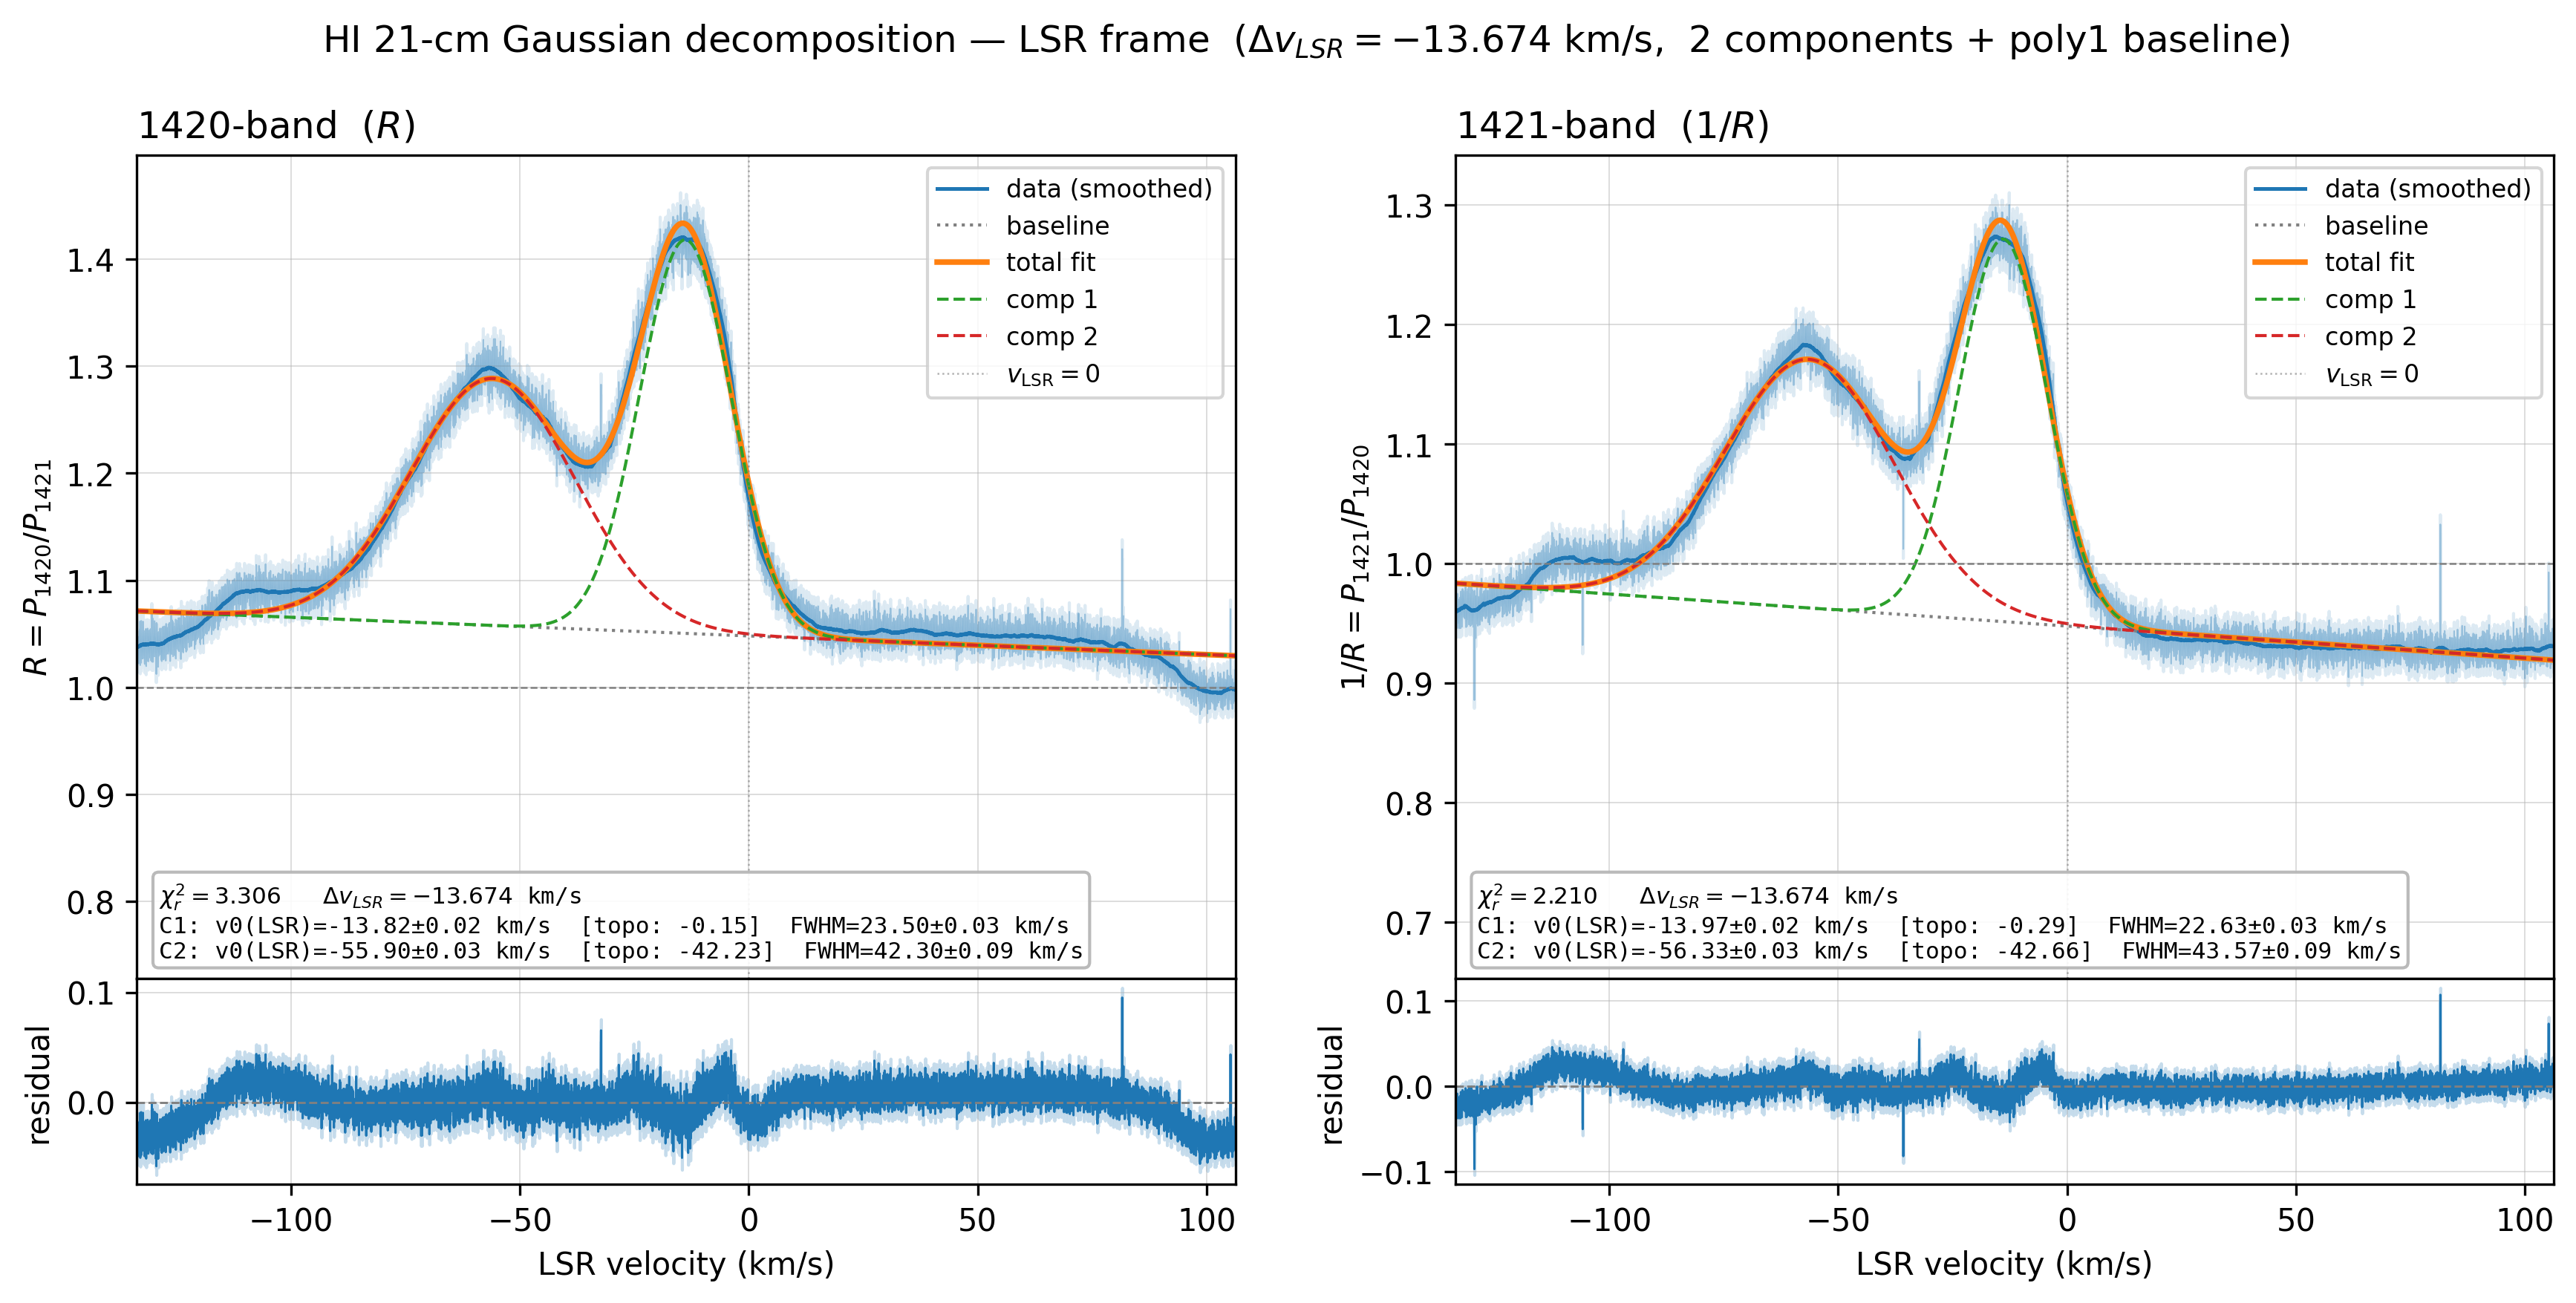

In [8]:
v_grid = np.linspace(VEL_FIT_MIN, VEL_FIT_MAX, 4000)
v_grid_lsr = v_grid + v_lsr_kms
comp_colors = [f'C{i + 2}' for i in range(len(INITIAL_GUESSES))]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 6),
    dpi=300,
    gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.0},
    sharex='col',
)

bands = [
    (
        ratio_profile.numerator_topo_velocity_kms,
        ratio_profile.peak_profile,
        ratio_profile.peak_sigma,
        ratio_profile.peak_profile_smooth,
        fit_peak,
        '1420-band  ($R$)',
        r'$R = P_{1420}/P_{1421}$',
    ),
    (
        ratio_profile.denominator_topo_velocity_kms,
        ratio_profile.dip_profile,
        ratio_profile.dip_sigma,
        ratio_profile.dip_profile_smooth,
        fit_dip,
        '1421-band  ($1/R$)',
        r'$1/R = P_{1421}/P_{1420}$',
    ),
]

for col, (vel_kms, prof_raw, sigma_prof, prof_smooth, fit_result, band_label, ylabel) in enumerate(bands):
    ax_main = axes[0, col]
    ax_res = axes[1, col]

    vel_lsr = vel_kms + v_lsr_kms
    fit_curve = fit_result.model(v_grid)
    baseline = fit_result.baseline(v_grid)

    ax_main.fill_between(
        vel_lsr,
        prof_raw + 1 - sigma_prof,
        prof_raw + 1 + sigma_prof,
        alpha=0.15,
        color='C0',
    )
    ax_main.plot(vel_lsr, prof_raw + 1, lw=0.5, alpha=0.35, color='C0')
    ax_main.plot(vel_lsr, prof_smooth + 1, lw=1.2, color='C0', label='data (smoothed)')

    ax_main.plot(v_grid_lsr, baseline + 1, lw=1.0, ls=':', color='gray', label='baseline')
    ax_main.plot(v_grid_lsr, fit_curve + 1, lw=1.8, color='C1', label='total fit')

    for idx, component in enumerate(fit_result.components):
        comp = fit_result.component(v_grid, idx)
        ax_main.plot(
            v_grid_lsr,
            baseline + comp + 1,
            lw=1.0,
            ls='--',
            color=comp_colors[idx],
            label=f'comp {idx + 1}',
        )

    summary_lines = [
        r'$\chi^2_r=' + f'{fit_result.chi2_red:.3f}' + r'$   $\Delta v_{LSR}=' + f'{v_lsr_kms:+.3f}' + r'$ km/s',
    ]
    for idx, component in enumerate(fit_result.components):
        v0_lsr = component.center_kms + v_lsr_kms
        summary_lines.append(
            f'C{idx+1}: v0(LSR)={v0_lsr:+.2f}±{component.center_err:.2f} km/s'
            f'  [topo: {component.center_kms:+.2f}]'
            f'  FWHM={component.fwhm_kms:.2f}±{component.fwhm_err_kms:.2f} km/s'
        )
    ax_main.text(
        0.02,
        0.02,
        '\n'.join(summary_lines),
        transform=ax_main.transAxes,
        va='bottom',
        ha='left',
        family='monospace',
        fontsize=7.5,
        bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='0.7', alpha=0.9),
    )

    ax_main.axhline(1.0, color='gray', lw=0.6, ls='--')
    ax_main.axvline(0.0, color='gray', lw=0.6, ls=':', alpha=0.6, label=r'$v_\mathrm{LSR}=0$')
    ax_main.set_title(band_label, loc='left')
    ax_main.set_ylabel(ylabel)
    ax_main.legend(loc='upper right', fontsize=8)
    ax_main.grid(True, lw=0.4, alpha=0.5)
    ax_main.set_xlim(VEL_FIT_MIN + v_lsr_kms, VEL_FIT_MAX + v_lsr_kms)

    fit_at_data = fit_result.model(vel_kms[fit_result.mask])
    residuals = prof_raw[fit_result.mask] - fit_at_data
    ax_res.fill_between(
        vel_kms[fit_result.mask] + v_lsr_kms,
        residuals - sigma_prof[fit_result.mask],
        residuals + sigma_prof[fit_result.mask],
        alpha=0.25,
        color='C0',
    )
    ax_res.plot(vel_kms[fit_result.mask] + v_lsr_kms, residuals, lw=0.7, color='C0')
    ax_res.axhline(0, color='gray', lw=0.7, ls='--')
    ax_res.set_xlabel('LSR velocity (km/s)')
    ax_res.set_ylabel('residual')
    ax_res.grid(True, lw=0.4, alpha=0.5)

fig.suptitle(
    f'HI 21-cm Gaussian decomposition — LSR frame'
    r'  ($\Delta v_{LSR} = ' + f'{v_lsr_kms:+.3f}' + r'$ km/s,'
    f'  {fit_peak.n_components} components + poly{BASELINE_POLY_ORDER} baseline)'
)
plt.show()


## 5 · Simulated $R$ and $1/R$ from Continuum + Two HI Peaks

To illustrate the expected ratio signatures, we build a toy sky spectrum
$S(f)=C(f)+L(f)$ consisting of a smooth continuum plus two Gaussian HI peaks.
The two Gaussian line components are taken from the **1420-band fit results**
(component centroids and widths from `popt_peak`).

Using the same baseband offsets as the real 1420/1421 observations:

$$
R(\Delta f)=\frac{S(1420\,\mathrm{MHz}+\Delta f)}{S(1421\,\mathrm{MHz}+\Delta f)},
\qquad
\frac{1}{R}(\Delta f)=\frac{S(1421\,\mathrm{MHz}+\Delta f)}{S(1420\,\mathrm{MHz}+\Delta f)}.
$$

This noiseless simulation shows where peaks and dips should appear purely from
the LO shift and line shape.


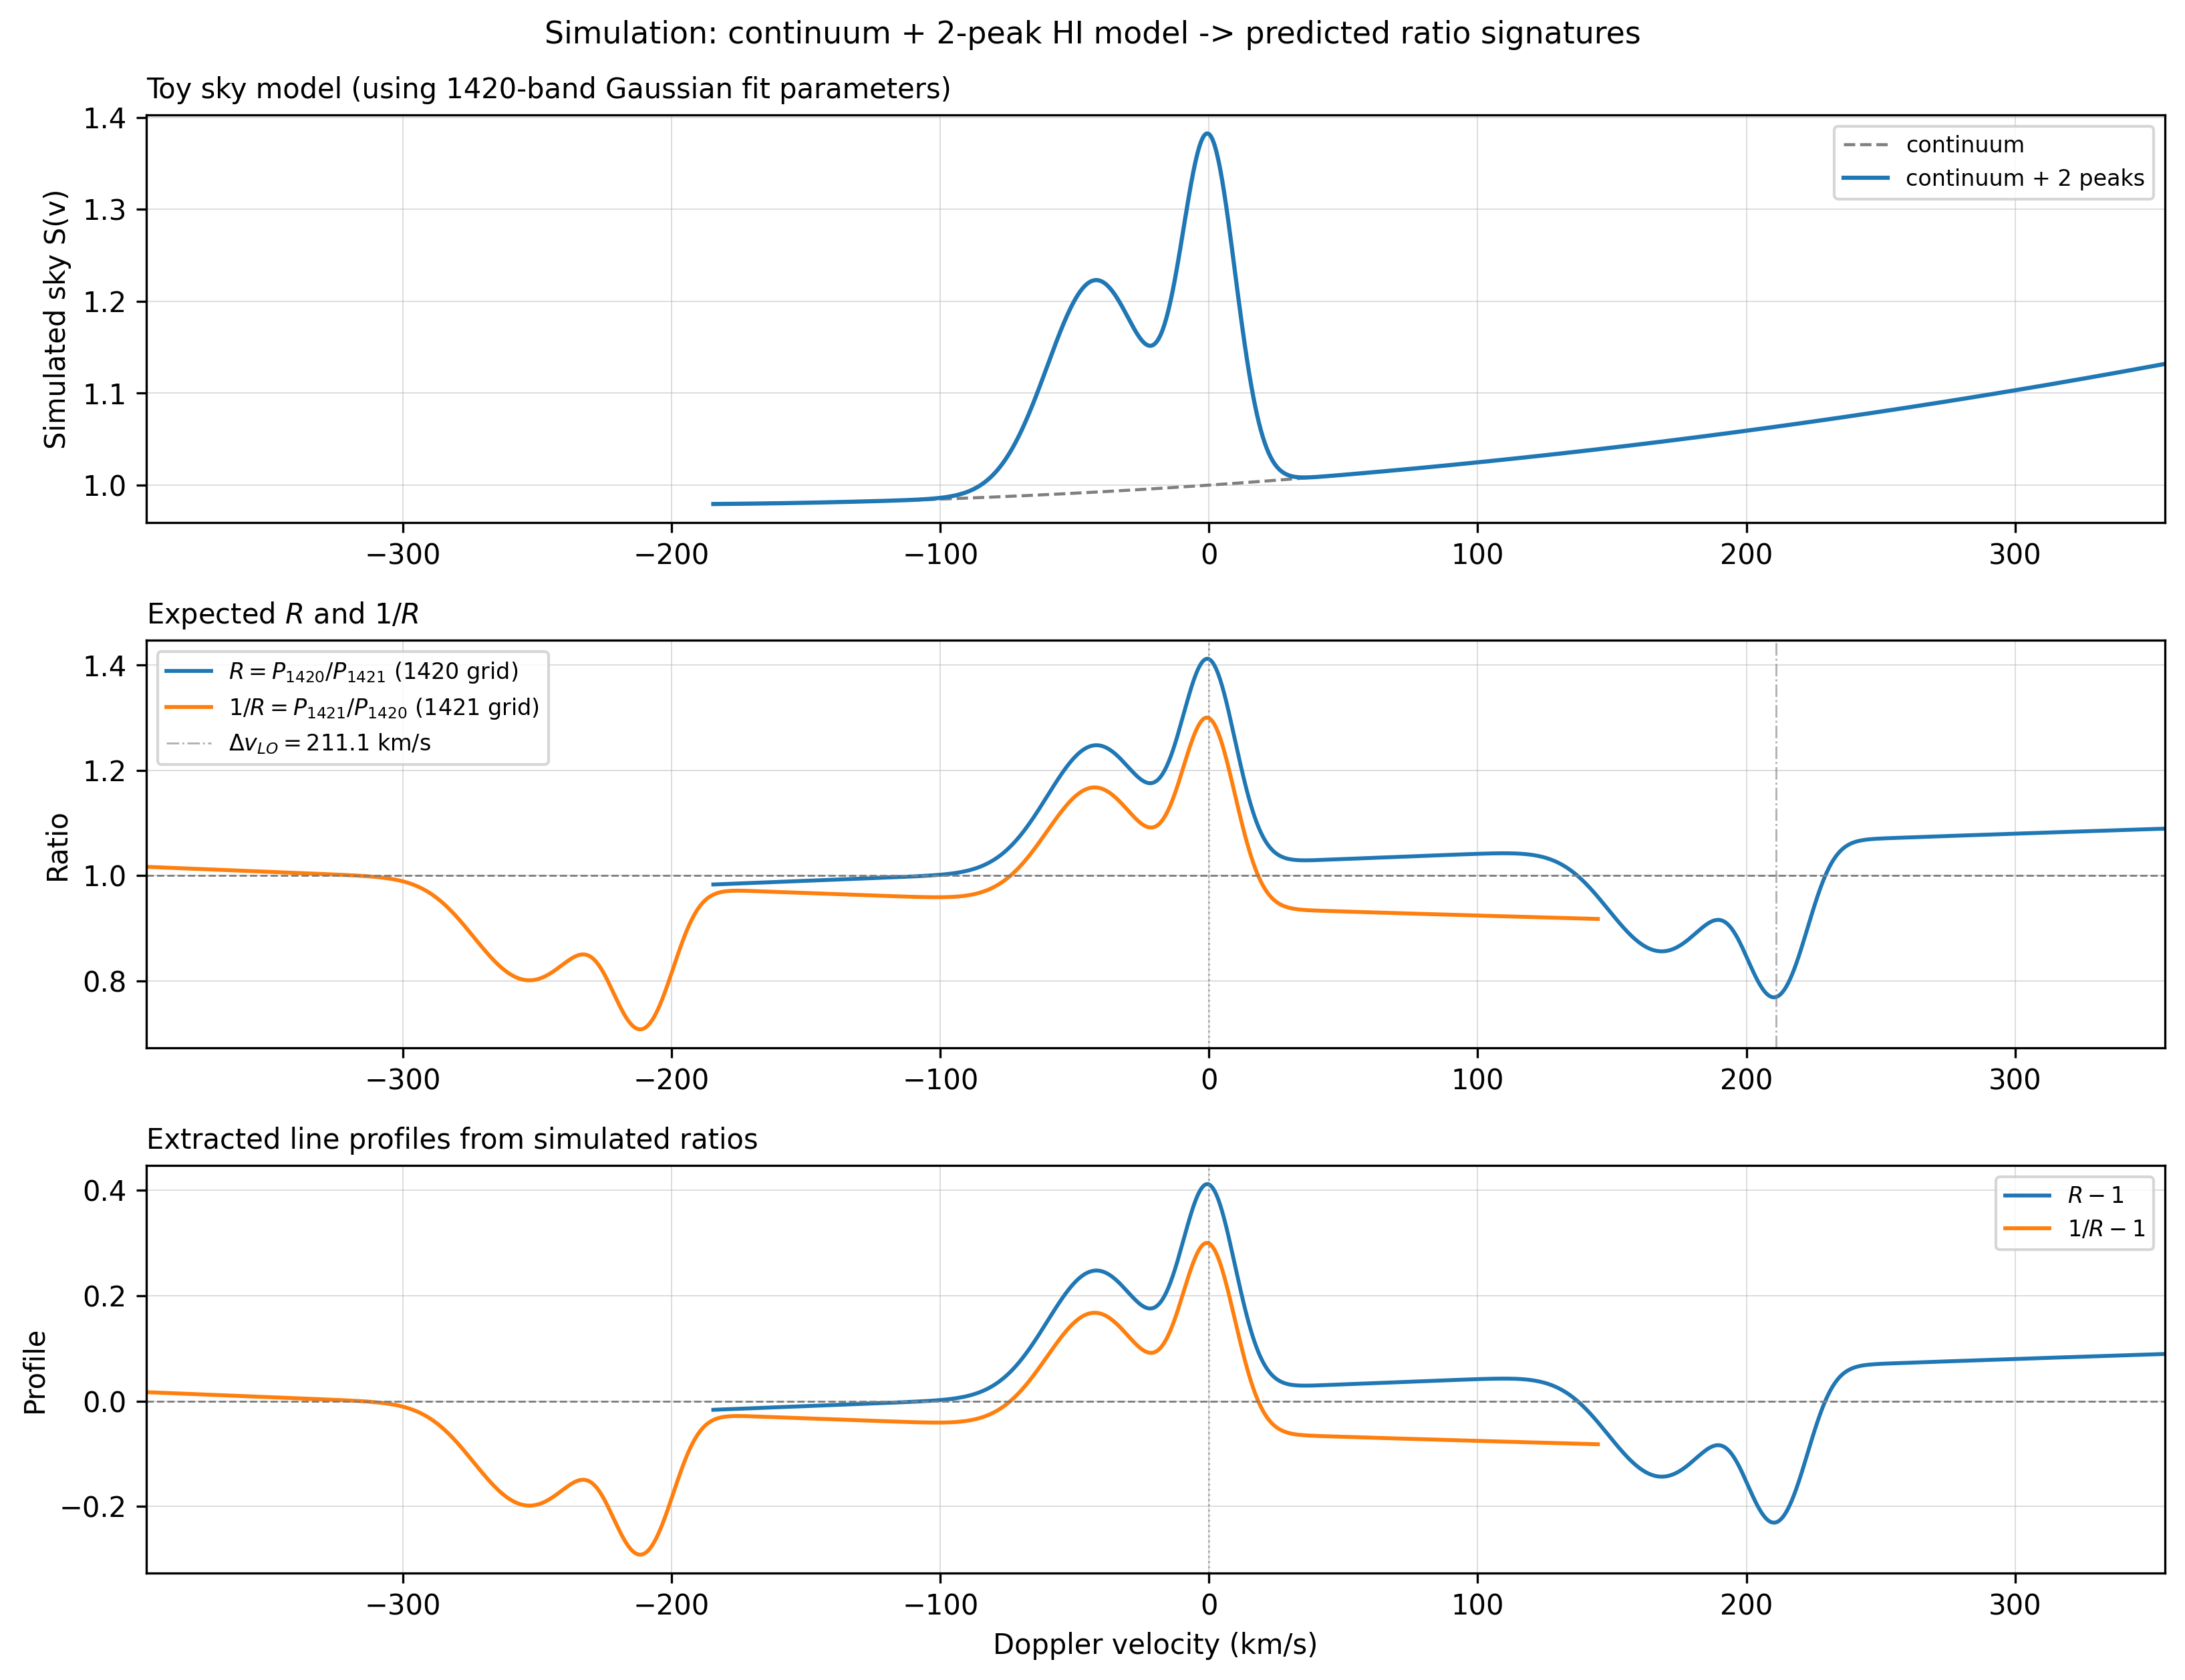

In [9]:
# Use fitted 1420-band components if available; otherwise fall back to current best-fit values.
if 'fit_peak' in globals():
    sim_params_1420 = np.array(fit_peak.popt[: 3 * fit_peak.n_components], dtype=float)
else:
    sim_params_1420 = np.array([0.35530, 6.33, 10.13, 0.20578, -34.99, 22.58], dtype=float)

simulation = simulate_hi_ratio_signature(
    long_1420,
    sim_params_1420,
    signal_center_freq_hz=1420e6,
    reference_center_freq_hz=1421e6,
    rest_freq_hz=HI_REST_FREQ_HZ,
)

fig, axes = plt.subplots(3, 1, figsize=(11, 8.5), dpi=300)

ord0 = np.argsort(simulation.signal_velocity_kms)
axes[0].plot(
    simulation.signal_velocity_kms[ord0],
    simulation.continuum_signal[ord0],
    color='gray',
    ls='--',
    lw=1.1,
    label='continuum',
)
axes[0].plot(
    simulation.signal_velocity_kms[ord0],
    simulation.sky_signal[ord0],
    color='C0',
    lw=1.5,
    label='continuum + 2 peaks',
)
axes[0].set_ylabel('Simulated sky S(v)')
axes[0].set_title('Toy sky model (using 1420-band Gaussian fit parameters)', loc='left', fontsize=10)
axes[0].grid(True, lw=0.4, alpha=0.5)
axes[0].legend(fontsize=8)

axes[1].plot(
    simulation.signal_velocity_kms,
    simulation.ratio,
    color='C0',
    lw=1.4,
    label=r'$R = P_{1420}/P_{1421}$ (1420 grid)',
)
axes[1].plot(
    simulation.reference_velocity_kms,
    simulation.inverse_ratio,
    color='C1',
    lw=1.4,
    label=r'$1/R = P_{1421}/P_{1420}$ (1421 grid)',
)
axes[1].axhline(1.0, color='gray', lw=0.7, ls='--')
axes[1].axvline(0.0, color='gray', lw=0.7, ls=':', alpha=0.6)
axes[1].axvline(
    simulation.lo_separation_kms,
    color='gray',
    lw=0.7,
    ls='-.',
    alpha=0.6,
    label=fr'$\Delta v_{{LO}}={simulation.lo_separation_kms:.1f}$ km/s',
)
axes[1].set_ylabel('Ratio')
axes[1].set_title('Expected $R$ and $1/R$', loc='left', fontsize=10)
axes[1].grid(True, lw=0.4, alpha=0.5)
axes[1].legend(fontsize=8)

axes[2].plot(simulation.signal_velocity_kms, simulation.ratio - 1.0, color='C0', lw=1.4, label=r'$R-1$')
axes[2].plot(simulation.reference_velocity_kms, simulation.inverse_ratio - 1.0, color='C1', lw=1.4, label=r'$1/R-1$')
axes[2].axhline(0.0, color='gray', lw=0.7, ls='--')
axes[2].axvline(0.0, color='gray', lw=0.7, ls=':', alpha=0.6)
axes[2].set_xlabel('Doppler velocity (km/s)')
axes[2].set_ylabel('Profile')
axes[2].set_title('Extracted line profiles from simulated ratios', loc='left', fontsize=10)
axes[2].grid(True, lw=0.4, alpha=0.5)
axes[2].legend(fontsize=8)

vmin = min(simulation.signal_velocity_kms.min(), simulation.reference_velocity_kms.min())
vmax = max(simulation.signal_velocity_kms.max(), simulation.reference_velocity_kms.max())
for ax in axes:
    ax.set_xlim(vmin, vmax)

fig.suptitle('Simulation: continuum + 2-peak HI model -> predicted ratio signatures', fontsize=11)
fig.tight_layout()
plt.show()
